Atividade 2 --- Análise de Regressão

### Contexto

Nesta atividade, será realizada a simulação de um conjunto de dados a partir de um modelo de regressão linear simples com parâmetros conhecidos. A partir desses dados, serão conduzidos procedimentos de inferência estatística, incluindo o teste de hipóteses para o coeficiente angular e a construção de intervalos de confiança, além da análise do efeito da centralização da variável explicativa sobre os parâmetros do modelo.

### 1.a) Simule um conjunto de dados com n pares ($Y_i,X_i$), e ajuste o modelo de regressão linear simples.

O modelo considerado é:
$Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i$

In [12]:
# modelo: Y_i = beta_0 + beta_1*X_i + erro_i

set.seed(260329)
n <- 25    # número de observações / tamanho da amostra
beta_0 <- 16    # os parâmetros
beta_1 <- 5

X <- runif(n,min = 10, max = 20) 
Erros <- rnorm(n, mean = 0, sd = 5) 
Y <- beta_0 + beta_1 * X + Erros

Foi gerado um conjunto de dados com n=20 observações, considerando o modelo $Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i$ ​ , onde $\varepsilon_i ∼ N( 0 , 𝜎^2 )$, independentes e identicamente distribuídos.

A covariável  $X_i$  foi simulada a partir de uma distribuição uniforme no intervalo [10, 20], enquanto o erro aleatório $\varepsilon_i$  foi gerado a partir de uma distribuição normal com média zero e desvio padrão igual a 5.

A variável resposta  $Y_i$  foi então construída de acordo com o modelo especificado.

---

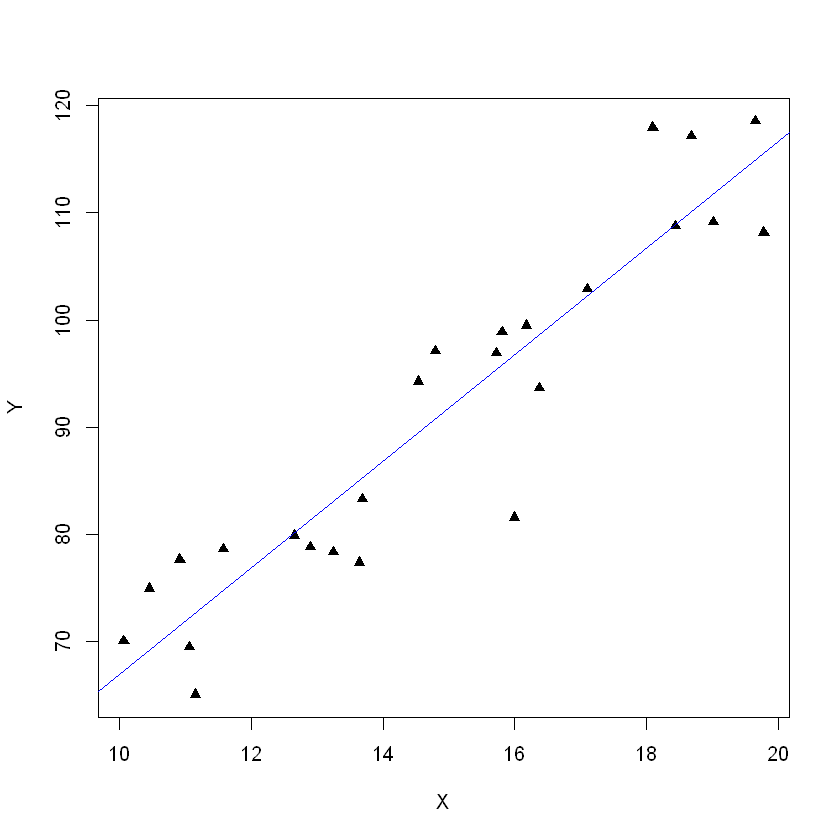

In [13]:
plot(X,Y, pch = 17)
modelo <- lm(Y ~ X) # regressão linear
abline(modelo, col = "blue") 


### b) Teste as hipóteses: $H_0: \beta_1 = 0 $ vs. $H_1: \beta_1 \neq 0$

In [3]:
modelo <- lm(Y ~ X)
summary(modelo)$coef

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),17.151910,6.0500725,2.834993,9.382863e-03
X,4.976662,0.3990658,12.470782,1.021484e-11


Foi ajustado um modelo de regressão linear simples para avaliar a relação entre $X$ e $Y$.

As estimações foram:  $\hat{\beta_0} = 0.6 $ $\hat{\beta_1}  = 5.19$

A estatística usada para fazer o teste é $t =\frac{\hat{\beta_1} - \beta_1}{EP(\hat{\beta_1})} = \frac{\hat{\beta_1} - \beta_1}{\sqrt{MSE/\sum (X_i-\bar{X})^2}}$, e essa estatística sob $H_0$ segue uma distribuição $t$ de student com n-2 graus de liberdade


A partir dos resultados do teste feito acima, observa-se que o coeficiente associado a $X$ é estatisticamente significativo, com valor-p (5.86e-11) próximo de zero, .

Dessa forma, rejeitamos $H_0$, há evidência de que $\beta_1 \neq 0$, indicando uma relação linear entre $X$ e $Y$ no range de [10; 20].

---


### c) Determine um intervalo de confiança para $\beta_1$ Interprete o intervalo

Intervalo de confiança para $\beta_1$:

In [4]:
confint(modelo)

,2.5 %,97.5 %
(Intercept),4.636382,29.667439
X,4.151132,5.802193


O intervalo de confiança de 95% para $\beta_1$, dado por [4.15; 5.8] não contém o valor zero, o que reforça a evidência de que o coeficiente de inclinação é diferente de zero e isso indica que, em média, um aumento unitário em $X$ está associado a um aumento entre 4.15 e 5.8 unidades em $Y$.

Além disso, o intervalo está próximo do valor verdadeiro utilizado na simulação ($\beta_1 = 5$), indicando que o estimador $\hat{\beta_1}$ é adequado neste contexto.

---

### d) Centralize o modelo. Ajuste o modelo centralizado. Interprete $\beta_0 ^ {*}$ e $\beta_1$. Compare os modelos

$X$ centralizado é dado por:


$X^* = X - \bar{X}$

Assim, $Y_i^* = \beta_0^* + \beta_1 X_i^* + \varepsilon_i$

onde $\beta_0^* = \beta_0 + \beta_1 \bar{X}$


Em seguida, ajustou-se um novo modelo de regressão utilizando $X^*$.

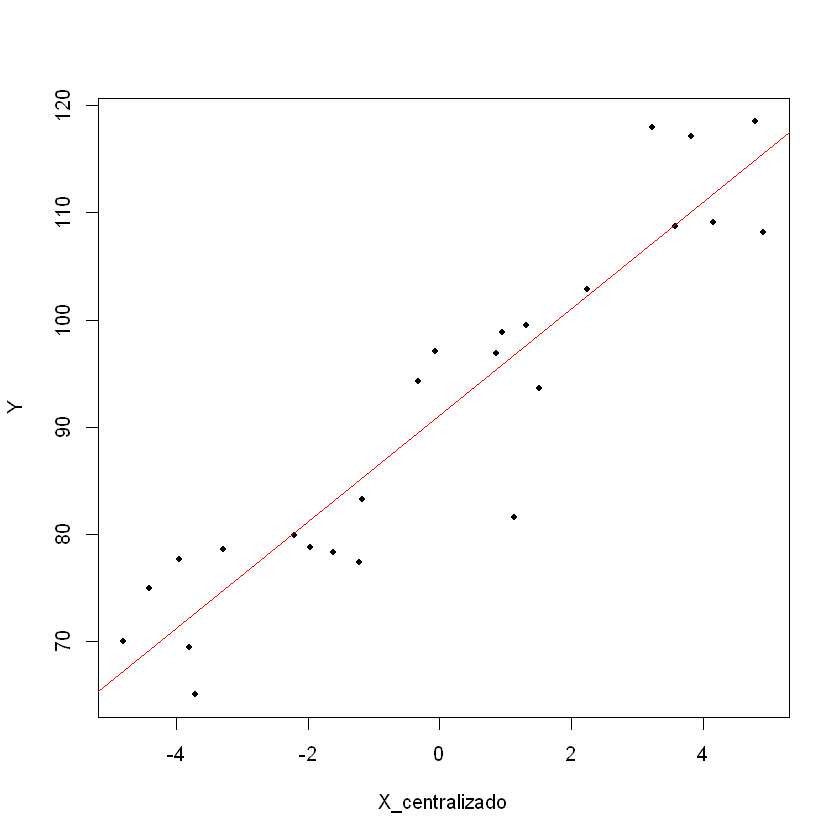

In [5]:
X_centralizado <- X - mean(X)

plot(X_centralizado,Y, pch = 20)
modelo_centralizado <- lm(Y ~ X_centralizado)
abline(modelo_centralizado, col = "red") 

In [13]:
mean(Y)

[1] 91.10512

In [6]:
summary(modelo_centralizado)$coef

confint(modelo_centralizado)

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),91.105120,1.1987810,75.99814,3.969212e-29
X_centralizado,4.976662,0.3990658,12.47078,1.021484e-11


,2.5 %,97.5 %
(Intercept),88.625253,93.584987
X_centralizado,4.151132,5.802193


As estimações foram:  $\hat{\beta_0^*} = 91.11 $ e $\hat{\beta_1}  = 4.97$

O intervalo de confiança de 95% para $\beta_1$ não mudou, continua sendo [4.4; 5.9]. E sobre a hipótese $H_0: \beta_1 = 0$, é rejeitada por valor p pequeno. Isso é esperado já que o modelo centralizado preserva a inferência a $\beta_1$

Comparando os coeficientes dos dois modelos, observa-se que:

- O estimador $\hat{\beta_1}$ para $\beta_1$ e o seu intervalo de confiança permanecem inalterados nos dois modelos.
- O intercepto é modificado ($\beta_0 \neq \beta_0^*$).

No modelo original, o intercepto representa o valor esperado de $Y$ quando $X = 0$, o que pode não ter interpretação prática, especialmente quando esse valor está fora do intervalo observado. 

Enquanto no modelo centralizado, o intercepto ${\beta_0}^*$ passa a representar o valor esperado de  $Y$ quando $X = \bar{X}$.

Assim, a centralização não altera a inclinação da reta, pois a inclinação continua sendo $\beta_1$ (que representa a variação esperada em $Y$ associado a um aumento unitário em $X$), mas modifica a interpretação do intercepto, tornando-o mais informativo quando o valor médio de $X$ é relevante.

---

Gráfico de dispersão para comparação :

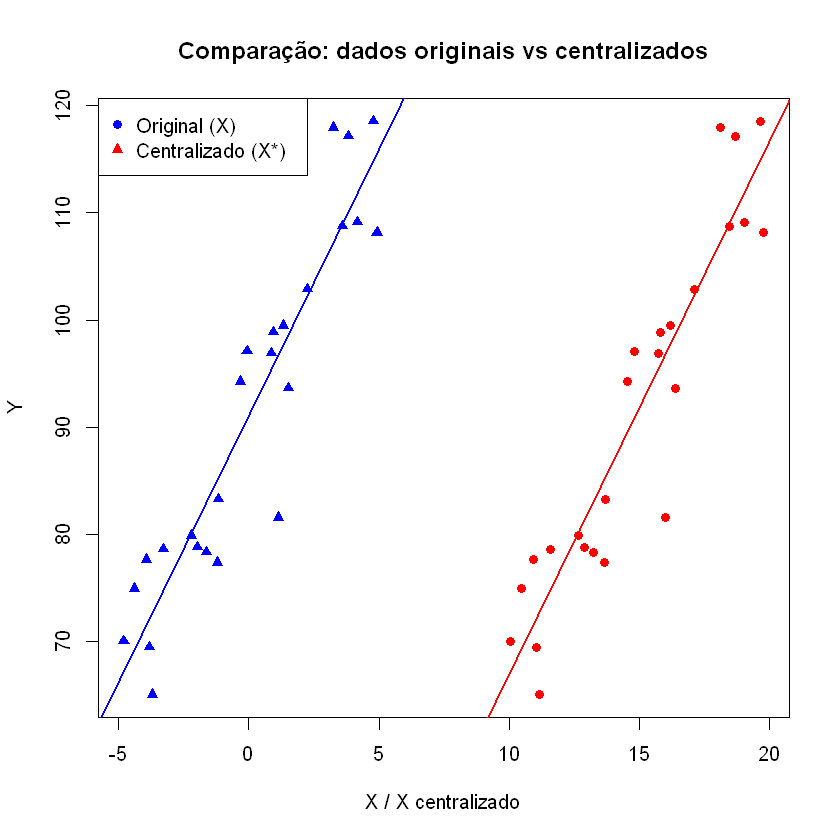

In [7]:
plot(X, Y,
     col = "red",
     pch = 16,
     xlab = "X / X centralizado",
     ylab = "Y",
     main = "Comparação: dados originais vs centralizados",
     xlim = range(c(X, X_centralizado))
)

#pontos do modelo centralizado
points(X_centralizado, Y,
       col = "blue",
       pch = 17)

#retas
abline(modelo, col = "red", lwd = 2)
abline(modelo_centralizado, col = "blue", lwd = 2)


# legenda
legend("topleft",
       legend = c("Original (X)", "Centralizado (X*)"),
       col = c("blue", "red"),
       pch = c(16, 17))

In [19]:
set.seed(20260408)
X0 <- runif(1,min = 10, max = 20) 
X0
X0 = 17.82

[1] 17.82427


--- Cálculo manual ---


Valor predito Y0_hat = 105.836 
Erro padrão = 1.683 
IC 95% para E(Y0): [ 102.355 , 109.318 ]

--- Usando predict ---
      fit      lwr      upr
1 105.836 102.3545 109.3175

Interpretação: Com 95% de confiança, o valor esperado de Y quando X = 17.82 está entre 102.355 e 109.318 .


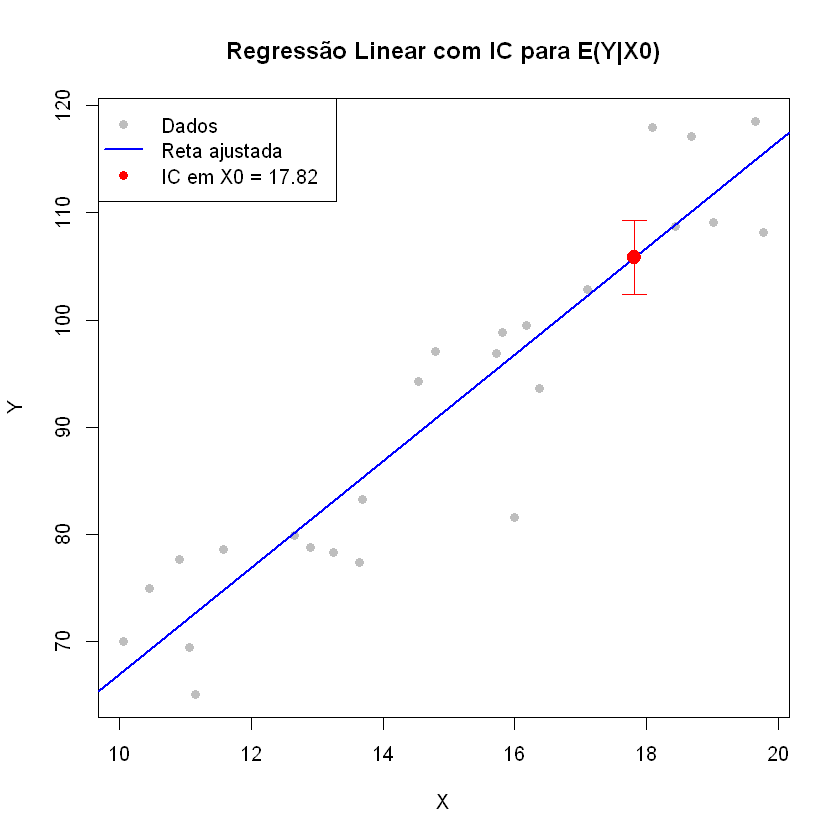

In [20]:
# 4. Cálculo manual do IC para E(Y0)
# Coeficientes
coefs <- coef(modelo)
Y0_hat <- coefs[1] + coefs[2] * X0

# MSE (quadrado do erro padrão residual)
MSE <- summary(modelo)$sigma^2

# Soma de quadrados de X
Sxx <- sum((X - mean(X))^2)

# Erro padrão da média predita
SE_Y0 <- sqrt(MSE/n + MSE * (X0 - mean(X))^2 / Sxx)

# Quantil t com n-2 graus de liberdade
t_crit <- qt(0.975, df = n-2)

# Intervalo de confiança
IC_inf <- Y0_hat - t_crit * SE_Y0
IC_sup <- Y0_hat + t_crit * SE_Y0

cat("\n--- Cálculo manual ---\n")
cat("Valor predito Y0_hat =", round(Y0_hat, 3), "\n")
cat("Erro padrão =", round(SE_Y0, 3), "\n")
cat("IC 95% para E(Y0): [", round(IC_inf, 3), ",", round(IC_sup, 3), "]\n")

# 5. Usando a função predict (mais direto)
pred <- predict(modelo, newdata = data.frame(X = X0), 
                interval = "confidence", level = 0.95)

cat("\n--- Usando predict ---\n")
print(pred)

# 6. Interpretação (texto)
cat("\nInterpretação: Com 95% de confiança, o valor esperado de Y quando X =", X0, 
    "está entre", round(pred[2],3), "e", round(pred[3],3), ".\n")

# 7. Gráfico opcional para visualização
plot(X, Y, main = "Regressão Linear com IC para E(Y|X0)", 
     xlab = "X", ylab = "Y", pch = 19, col = "gray")
abline(modelo, col = "blue", lwd = 2)
points(X0, Y0_hat, col = "red", pch = 19, cex = 1.5)
arrows(X0, IC_inf, X0, IC_sup, angle = 90, code = 3, col = "red", length = 0.1)
legend("topleft", legend = c("Dados", "Reta ajustada", 
                             paste0("IC em X0 = ", X0)), 
       col = c("gray", "blue", "red"), pch = c(19, NA, 19), 
       lty = c(NA, 1, NA), lwd = c(NA, 2, NA))

In [21]:
# --- Método 2: cálculo manual para entendimento ---
Y0_hat <- coef(modelo)[1] + coef(modelo)[2] * X0
MSE <- summary(modelo)$sigma^2
n <- length(Y)
Sxx <- sum((X - mean(X))^2)
t_crit <- qt(0.975, df = n - 2)

erro_padrao_pred <- sqrt(MSE * (1 + 1/n + (X0 - mean(X))^2 / Sxx))
IP_inf <- Y0_hat - t_crit * erro_padrao_pred
IP_sup <- Y0_hat + t_crit * erro_padrao_pred

cat("\nCálculo manual:\n")
cat("Y0_hat =", round(Y0_hat, 3), "\n")
cat("Erro padrão de predição =", round(erro_padrao_pred, 3), "\n")
cat("IP 95%: [", round(IP_inf, 3), ",", round(IP_sup, 3), "]\n")

# Comparação com o IC para média (já calculado anteriormente)
pred_ic <- predict(modelo, newdata = data.frame(X = X0),
                   interval = "confidence", level = 0.95)
cat("\nIC para média (para comparação):\n")
print(pred_ic)


Cálculo manual:
Y0_hat = 105.836 
Erro padrão de predição = 6.226 
IP 95%: [ 92.957 , 118.715 ]

IC para média (para comparação):
      fit      lwr      upr
1 105.836 102.3545 109.3175


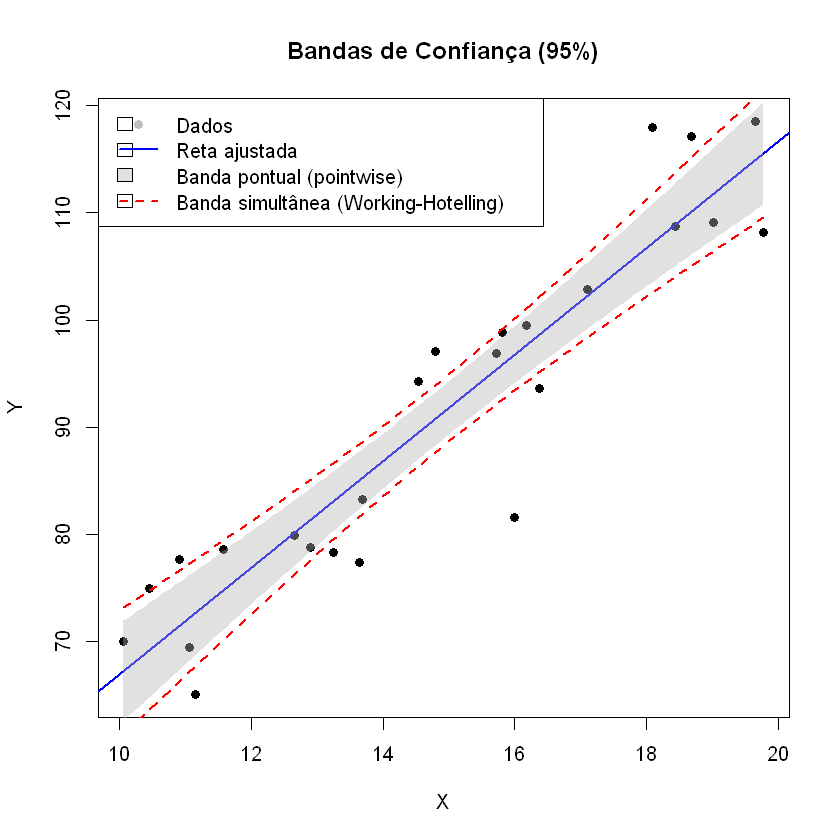

In [23]:
#banda de confiança:::::::
MSE <- summary(modelo)$sigma^2
Sxx <- sum((X - mean(X))^2)
n <- length(X)

# Sequência de valores de X para a banda (dentro da amplitude observada)
X_seq <- seq(min(X), max(X), length.out = 100)
Y_hat <- predict(modelo, newdata = data.frame(X = X_seq))

# Erro padrão da média (ponto a ponto)
SE_fit <- sqrt(MSE * (1/n + (X_seq - mean(X))^2 / Sxx))

# --- Banda pontual (pointwise) com nível 95% ---
t_crit <- qt(0.975, df = n-2)
lower_pointwise <- Y_hat - t_crit * SE_fit
upper_pointwise <- Y_hat + t_crit * SE_fit

# --- Banda simultânea de Working-Hotelling (95%) ---
F_crit <- qf(0.95, df1 = 2, df2 = n-2)
w <- sqrt(2 * F_crit)   # fator de largura
lower_simult <- Y_hat - w * SE_fit
upper_simult <- Y_hat + w * SE_fit

# --- Gráfico comparativo ---
plot(X, Y, pch = 19, col = "black", main = "Bandas de Confiança (95%)")
abline(modelo, col = "blue", lwd = 2)

# Banda pontual (cinza claro)
polygon(c(X_seq, rev(X_seq)), c(lower_pointwise, rev(upper_pointwise)),
        col = rgb(0.7, 0.7, 0.7, 0.4), border = NA)

# Banda simultânea (vermelho tracejado)
lines(X_seq, lower_simult, col = "red", lty = 2, lwd = 2)
lines(X_seq, upper_simult, col = "red", lty = 2, lwd = 2)

legend("topleft", legend = c("Dados", "Reta ajustada", 
                             "Banda pontual (pointwise)", 
                             "Banda simultânea (Working-Hotelling)"),
       col = c("gray", "blue", rgb(0.7,0.7,0.7,0.4), "red"),
       lty = c(NA, 1, 1, 2), lwd = c(NA, 2, NA, 2),
       pch = c(19, NA, NA, NA), fill = c(NA, NA, rgb(0.7,0.7,0.7,0.4), NA))